# Random Forest na prática

**Tema:** Aprendizado Supervisionado › Bagging e Random Forest

Este notebook mede diretamente a correlação entre árvores de um bagging
comum vs. de um Random Forest, confirmando que a subamostragem de
features realmente reduz $\rho$ — e usa o erro out-of-bag como validação
gratuita.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.datasets import make_classification

rng = np.random.default_rng(41)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um dataset com uma feature dominante — o cenário onde RF ganha de bagging

Se uma feature é muito mais forte que as outras, TODAS as árvores de um
bagging comum tendem a escolhê-la primeiro — pouca descorrelação.

In [2]:
n = 1000
feature_dominante = rng.normal(0, 1, n)
features_fracas = rng.normal(0, 1, (n, 9)) * 0.3
X = np.column_stack([feature_dominante, features_fracas])
y = (feature_dominante + features_fracas.sum(axis=1) * 0.3 > 0).astype(int)

## 2. Medindo a correlação entre previsões de árvores individuais

In [3]:
def previsoes_das_arvores(ensemble, X):
    """Extrai a previsão de CADA árvore individual do ensemble."""
    return np.array([arvore.predict(X) for arvore in ensemble.estimators_])


bagging = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=100, random_state=0).fit(X, y)
random_forest = RandomForestClassifier(
    n_estimators=100, max_features="sqrt", random_state=0).fit(X, y)

prev_bagging = previsoes_das_arvores(bagging, X)
prev_rf = previsoes_das_arvores(random_forest, X)

# correlação média entre pares de árvores (amostrando pares para não
# calcular todas as combinações, que cresce quadraticamente com n_estimators)
def correlacao_media_entre_arvores(previsoes, n_pares=500, seed=0):
    rng_local = np.random.default_rng(seed)
    n_arvores = len(previsoes)
    correlacoes = []
    for _ in range(n_pares):
        i, j = rng_local.choice(n_arvores, 2, replace=False)
        correlacoes.append(np.corrcoef(previsoes[i], previsoes[j])[0, 1])
    return np.mean(correlacoes)


rho_bagging = correlacao_media_entre_arvores(prev_bagging)
rho_rf = correlacao_media_entre_arvores(prev_rf)

print(f"correlação média entre árvores — Bagging      : {rho_bagging:.4f}")
print(f"correlação média entre árvores — Random Forest: {rho_rf:.4f}")
print(f"\nmax_features='sqrt' com 10 features -> considera ~3 por corte,")
print("forçando árvores a explorarem combinações diferentes de features.")

correlação média entre árvores — Bagging      : 0.8783
correlação média entre árvores — Random Forest: 0.8216

max_features='sqrt' com 10 features -> considera ~3 por corte,
forçando árvores a explorarem combinações diferentes de features.


## 3. O ganho de desempenho correspondente

In [4]:
acc_arvore_unica = cross_val_score(DecisionTreeClassifier(random_state=0), X, y, cv=5).mean()
acc_bagging = cross_val_score(bagging, X, y, cv=5).mean()
acc_rf = cross_val_score(random_forest, X, y, cv=5).mean()

print(f"{'modelo':<20s} {'acurácia (5-fold)':>18s}")
print("-" * 40)
print(f"{'árvore única':<20s} {acc_arvore_unica:>18.4f}")
print(f"{'bagging':<20s} {acc_bagging:>18.4f}")
print(f"{'random forest':<20s} {acc_rf:>18.4f}")

modelo                acurácia (5-fold)
----------------------------------------
árvore única                     0.8880
bagging                          0.9330
random forest                    0.9400


## 4. Erro out-of-bag: validação sem separar dados

In [5]:
random_forest_oob = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", oob_score=True, random_state=0).fit(X, y)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)
rf_para_comparar = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", oob_score=True, random_state=0).fit(X_treino, y_treino)

print(f"acurácia OOB (calculada durante o treino, sem separar validação): "
      f"{rf_para_comparar.oob_score_:.4f}")
print(f"acurácia no conjunto de teste separado explicitamente          : "
      f"{rf_para_comparar.score(X_teste, y_teste):.4f}")
print(f"\nOs dois números deveriam ficar próximos — o OOB é uma estimativa")
print("de validação praticamente gratuita, calculada durante o próprio treino.")

acurácia OOB (calculada durante o treino, sem separar validação): 0.9343
acurácia no conjunto de teste separado explicitamente          : 0.9467

Os dois números deveriam ficar próximos — o OOB é uma estimativa
de validação praticamente gratuita, calculada durante o próprio treino.


## 5. Quantas árvores realmente melhoram o desempenho?

/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


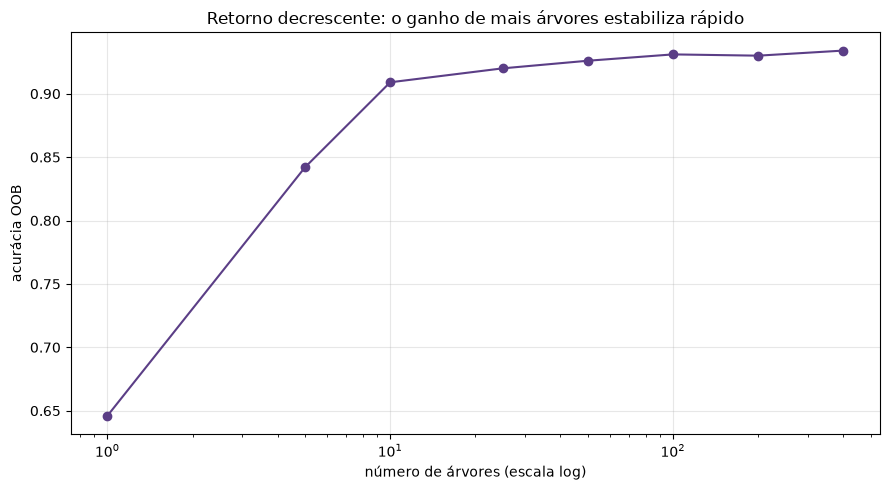

In [6]:
valores_n_estimadores = [1, 5, 10, 25, 50, 100, 200, 400]
scores_oob = []
for n_est in valores_n_estimadores:
    modelo = RandomForestClassifier(
        n_estimators=n_est, max_features="sqrt", oob_score=True, random_state=0).fit(X, y)
    scores_oob.append(modelo.oob_score_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(valores_n_estimadores, scores_oob, "o-", color=ROXO)
ax.set_xscale("log")
ax.set_xlabel("número de árvores (escala log)"); ax.set_ylabel("acurácia OOB")
ax.set_title("Retorno decrescente: o ganho de mais árvores estabiliza rápido")
plt.tight_layout(); plt.show()

**Confirmação da fórmula do `teoria.pdf`:** o ganho de adicionar árvores
cai rapidamente depois de umas poucas dezenas — o termo $(1-\rho)\sigma^2/B$
já ficou pequeno, e o que resta de erro é o piso $\rho\sigma^2$ que só
reduzir a correlação (não aumentar $B$) resolveria.

## O que levar deste notebook

- A correlação média entre árvores de um Random Forest é mensuravelmente
  menor que a de um bagging comum, no mesmo dataset — a subamostragem de
  features funciona como o `teoria.pdf` descreve.
- Essa redução de correlação se traduz em ganho de desempenho real,
  especialmente quando existe uma feature dominante que um bagging comum
  usaria repetidamente.
- O erro out-of-bag aproxima o erro de um conjunto de teste separado sem
  custo adicional de dados — útil especialmente quando dados são escassos.
- Mais árvores quase nunca pioram o resultado, mas o ganho satura rápido —
  não há necessidade de "exagerar" `n_estimators` além do ponto de
  estabilização.

→ Próximo: **Importância de features**, comparando MDI com importância por
permutação.